# Duplicate Payment Risk Predictor
## BPI P2P OCEL 2.0 — Process Mining Portfolio · Project 2

This model operationalizes the highest-priority finding from the OCPM audit (Project 1):
188 payment objects executed 2–5×, exposing €2.39M in duplicate payments over 30 months
with no automated detection mechanism in place.

**Objective:** Predict which purchase orders are at risk of generating a duplicate payment,
enabling proactive intervention before execution.

**Approach:** Feature engineering from process behaviour (event sequences, timing,
conformance signals) → Random Forest binary classifier → feature importance analysis.

## 1. Environment Setup

In [12]:
# ============================================================
# PROJECT 2: Duplicate Payment Risk Predictor
# BPI P2P OCEL 2.0 — Process Mining Portfolio
# ============================================================
# Operationalizes the highest-priority finding from the OCPM audit
# (Project 1): 188 payment objects executed 2–5×, exposing €2.39M
# in duplicate payments over 30 months with no automated detection.
#
# This model predicts duplicate payment risk at the purchase order
# level, enabling proactive intervention before execution.
# ============================================================

import json
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime

print("✅ Libraries loaded.")

✅ Libraries loaded.


## 2. Data Loading

In [13]:
# Load the OCEL 2.0 JSON log.
# The file encodes 7 object types and 10 activity types across
# 30 months of SAP P2P data (Apr 2022 – Oct 2024).

with open("ocel2-p2p.json", "r") as f:
    data = json.load(f)

print(f"Events  : {len(data['events'])}")
print(f"Objects : {len(data['objects'])}")

Events  : 14671
Objects : 9543


## 3. Exploratory Data Analysis

In [14]:
# Inspect attribute coverage across all purchase orders.
# Determines whether SAP header fields carry usable signal for feature engineering.

purchase_orders = {}

for obj in data['objects']:
    if obj['type'] == 'purchase_order':
        attrs = {a['name']: a['value'] for a in obj.get('attributes', [])}
        purchase_orders[obj['id']] = attrs

attr_names = list(list(purchase_orders.values())[0].keys())

print(f"Purchase orders extracted : {len(purchase_orders)}")
print()
print(f"{'Attribute':<45} {'Coverage %'}")
print("-" * 55)
for attr in attr_names:
    count = sum(1 for attrs in purchase_orders.values() if attrs.get(attr, ''))
    pct = round(count / len(purchase_orders) * 100, 1)
    print(f"{attr:<45} {pct}%")

Purchase orders extracted : 1598

Attribute                                     Coverage %
-------------------------------------------------------
Purchasing Group (EKKO-EKGRP)                 0.0%
Purchasing Organization (EKKO-EKORG)          0.0%
Document Type (EKKO-BSART)                    0.0%
Release Status (EKKO-FRGZU)                   0.0%
Vendor (EKKO-LIFNR)                           0.0%
new_value                                     0.0%


All 1,598 purchase order objects were extracted. Attribute inspection reveals that all SAP
header fields (Vendor, Purchasing Group, Document Type, etc.) are unpopulated across the
entire dataset — consistent with the anonymisation applied to this log. PO-level static
attributes cannot be used as model features. Feature engineering will rely entirely on
process behaviour derived from the event log. The `new_value` field is an extraction
artefact with no business meaning and will be excluded.

In [15]:
# Audit event types and their frequency across the log.
# Establishes the activity vocabulary available for feature engineering.

event_type_counts = Counter(e['type'] for e in data['events'])

print(f"{'Event Type':<45} {'Count'}")
print("-" * 55)
for etype, count in sorted(event_type_counts.items(), key=lambda x: -x[1]):
    print(f"{etype:<45} {count}")

Event Type                                    Count
-------------------------------------------------------
Create Goods Receipt                          4042
Create Invoice Receipt                        1941
Perform Two-Way Match                         1941
Approve Purchase Order                        1598
Create Purchase Order                         1598
Execute Payment                               1166
Create Request for Quotation                  927
Create Purchase Requisition                   729
Approve Purchase Requisition                  607
Delegate Purchase Requisition Approval        122


The log covers 10 activity types spanning the full P2P cycle. Key observations:

- `Create Purchase Order` and `Approve Purchase Order` each appear exactly 1,598 times
  (one per PO), confirming clean header-level coverage with no missing initiations
- `Execute Payment` appears 1,166 times across 1,598 POs (fewer than one per PO on average),
  yet some POs accumulate multiple executions, which is the anomaly this model targets
- `Create Purchase Requisition` (729) and `Approve Purchase Requisition` (607) fall below
  the expected 927 — confirming the maverick buying deviation from Project 1, where 198
  requisitions bypassed the standard approval flow entirely

In [16]:
# Map each event to its associated purchase order(s) and sort chronologically.
# In OCEL 2.0, object relationships are stored per event as {objectId, qualifier} pairs.

po_events = defaultdict(list)

for event in data['events']:
    po_ids = [
        r['objectId'] for r in event.get('relationships', [])
        if r['objectId'].startswith('purchase_order:')
    ]
    for po_id in po_ids:
        po_events[po_id].append({
            'event_id'  : event['id'],
            'event_type': event['type'],
            'timestamp' : event['time']
        })

for po_id in po_events:
    po_events[po_id].sort(key=lambda x: x['timestamp'])

print(f"POs with at least one linked event : {len(po_events)}")
print()

sample_po = 'purchase_order:820'
print(f"Event sequence for {sample_po}:")
for e in po_events[sample_po]:
    print(f"  {e['timestamp']}  →  {e['event_type']}")

POs with at least one linked event : 1598

Event sequence for purchase_order:820:
  2023-08-17T15:26:00.000Z  →  Create Purchase Order
  2023-08-23T04:17:00.000Z  →  Approve Purchase Order
  2023-08-23T08:07:00.000Z  →  Create Goods Receipt
  2023-08-24T22:47:00.000Z  →  Create Goods Receipt
  2023-08-25T22:10:00.000Z  →  Create Goods Receipt
  2023-08-30T21:08:00.000Z  →  Create Goods Receipt
  2023-09-01T20:06:00.000Z  →  Execute Payment


All 1,598 purchase orders are linked to at least one event, confirming no orphaned PO
objects in the log. The sample sequence for `purchase_order:820` illustrates a fully
compliant P2P path: Create → Approve → multiple Goods Receipts → single Payment execution,
with no deviations. This serves as a baseline reference for what a clean process trace
looks like before we characterise anomalous behaviour.

## 4. Label Creation

Target variable: binary flag indicating whether a purchase order's linked payment object
was executed more than once. Derived from the payment object dimension to maintain
consistency with the Project 1 audit methodology.

In [17]:
# ============================================================
# TARGET LABEL CREATION
# ============================================================
# A purchase order is labelled 1 (duplicate payment risk) if its
# linked payment objects were executed more than once in the log.
# This directly operationalizes the audit finding: 188 payment
# objects executed 2–5×, exposing €2.39M over 30 months.
#
# Label derivation follows the payment object dimension, consistent
# with Project 1 methodology, rather than simply counting
# Execute Payment events per PO.
# ============================================================

# Step 1: count Execute Payment events per payment object
payment_exec_counts = defaultdict(int)

for event in data['events']:
    if event['type'] == 'Execute Payment':
        payment_ids = [
            r['objectId'] for r in event.get('relationships', [])
            if r['objectId'].startswith('payment:')
        ]
        for pay_id in payment_ids:
            payment_exec_counts[pay_id] += 1

# Step 2: identify payment objects executed more than once
duplicate_payments = {
    pay_id for pay_id, count in payment_exec_counts.items()
    if count > 1
}

print(f"Total payment objects      : {len(payment_exec_counts)}")
print(f"Executed more than once    : {len(duplicate_payments)}")

# Step 3: map duplicate payment objects back to their purchase orders
po_has_duplicate = defaultdict(int)

for event in data['events']:
    if event['type'] == 'Execute Payment':
        payment_ids = [
            r['objectId'] for r in event.get('relationships', [])
            if r['objectId'].startswith('payment:')
        ]
        po_ids = [
            r['objectId'] for r in event.get('relationships', [])
            if r['objectId'].startswith('purchase_order:')
        ]
        for pay_id in payment_ids:
            if pay_id in duplicate_payments:
                for po_id in po_ids:
                    po_has_duplicate[po_id] = 1

# Step 4: build the label series for all 1,598 POs
labels = {
    po_id: po_has_duplicate.get(po_id, 0)
    for po_id in po_events.keys()
}

label_counts = Counter(labels.values())
print(f"\nLabel distribution:")
print(f"  0 — no duplicate payment : {label_counts[0]}")
print(f"  1 — duplicate payment    : {label_counts[1]}")
print(f"  Positive rate            : {round(label_counts[1] / len(labels) * 100, 1)}%")

Total payment objects      : 927
Executed more than once    : 188

Label distribution:
  0 — no duplicate payment : 1283
  1 — duplicate payment    : 315
  Positive rate            : 19.7%


Label distribution confirms alignment with the Project 1 audit finding: 188 payment objects
were executed more than once, mapping to 315 at-risk purchase orders (19.7% of the dataset).
The class balance is reasonable for a binary classifier — no resampling required at this stage.

## 5. Feature Engineering

Features are derived exclusively from process behaviour observable before the first
Execute Payment event fires. Three candidate features were removed during development
due to data leakage:

- `payment_count` and `payment_gap_days` — direct post-execution counts, only knowable
  after payments have already fired
- `event_count` — inflated on duplicate-risk POs by repeated Execute Payment events,
  revealed as a proxy for execution count via class-stratified mean analysis

Two features from payment object attributes — invoice amount and payment method — were
added after OCEL object graph inspection and confirmed as legitimate pre-payment signals:
`pay_amount` equals the invoice credit amount on every PO (correlation = 1.0), confirming
it is recorded before execution.

In [18]:
# ============================================================
# FEATURE ENGINEERING — LEAKAGE-FREE
# ============================================================
# Prediction point: PO has been approved and goods received,
# but no payment has been executed yet. All features must be
# computable before Execute Payment fires.
#
# Timing features capture process velocity signals across the
# full PO lifecycle. Payment object attributes add financial
# and method-level signal confirmed as pre-execution data.
# ============================================================

def parse_ts(ts_str):
    return datetime.fromisoformat(ts_str.replace("Z", "+00:00"))

# Build payment object attribute lookup
payment_attrs = {}
for obj in data['objects']:
    if obj['type'] == 'payment':
        amounts = [
            a['value'] for a in obj.get('attributes', [])
            if a['name'] == 'Amount (DMBTR)' and a['value']
        ]
        methods = [
            a['value'] for a in obj.get('attributes', [])
            if a['name'] == 'Payment Method (ZLSCH)' and a['value']
        ]
        payment_attrs[obj['id']] = {
            'amount'        : amounts[0] if amounts else None,
            'payment_method': methods[0] if methods else None,
        }

# Link payment objects to their purchase orders
po_payment_ids = defaultdict(list)
for event in data['events']:
    po_ids = [
        r['objectId'] for r in event.get('relationships', [])
        if r['objectId'].startswith('purchase_order:')
    ]
    pay_ids = [
        r['objectId'] for r in event.get('relationships', [])
        if r['objectId'].startswith('payment:')
    ]
    for po_id in po_ids:
        po_payment_ids[po_id].extend(pay_ids)

# Build feature matrix
rows = []

for po_id, events in po_events.items():
    type_counts = Counter(e['event_type'] for e in events)

    goods_receipt_count = type_counts.get('Create Goods Receipt', 0)

    po_create_events  = [e for e in events if e['event_type'] == 'Create Purchase Order']
    po_approve_events = [e for e in events if e['event_type'] == 'Approve Purchase Order']
    payment_events    = [e for e in events if e['event_type'] == 'Execute Payment']
    gr_events         = [e for e in events if e['event_type'] == 'Create Goods Receipt']

    # Days: PO creation → first payment
    if po_create_events and payment_events:
        po_to_payment_days = (parse_ts(payment_events[0]['timestamp']) - parse_ts(po_create_events[0]['timestamp'])).days
    else:
        po_to_payment_days = -1

    # Days: PO creation → approval
    if po_create_events and po_approve_events:
        approval_lag_days = (parse_ts(po_approve_events[0]['timestamp']) - parse_ts(po_create_events[0]['timestamp'])).days
    else:
        approval_lag_days = -1

    # Days: approval → first payment
    if po_approve_events and payment_events:
        approval_to_payment_days = (parse_ts(payment_events[0]['timestamp']) - parse_ts(po_approve_events[0]['timestamp'])).days
    else:
        approval_to_payment_days = -1

    # Days: last goods receipt → first payment (negative = payment before GR)
    if gr_events and payment_events:
        last_gr = max(parse_ts(e['timestamp']) for e in gr_events)
        gr_to_payment_days = (parse_ts(payment_events[0]['timestamp']) - last_gr).days
    else:
        gr_to_payment_days = -1

    # Days: PO creation → last goods receipt
    if po_create_events and gr_events:
        last_gr = max(parse_ts(e['timestamp']) for e in gr_events)
        po_to_last_gr_days = (last_gr - parse_ts(po_create_events[0]['timestamp'])).days
    else:
        po_to_last_gr_days = -1

    # Days: first GR → last GR (spread-out deliveries = higher complexity)
    if len(gr_events) >= 2:
        gr_times = sorted(parse_ts(e['timestamp']) for e in gr_events)
        gr_spread_days = (gr_times[-1] - gr_times[0]).days
    else:
        gr_spread_days = 0

    # Payment object attributes
    pay_ids = list(set(po_payment_ids[po_id]))
    pay_amount = None
    pay_method = None
    if pay_ids:
        attrs = payment_attrs.get(pay_ids[0], {})
        raw_amount = attrs.get('amount')
        pay_amount = float(raw_amount) if raw_amount else None
        pay_method = attrs.get('payment_method')

    rows.append({
        'po_id'                   : po_id,
        'goods_receipt_count'     : goods_receipt_count,
        'po_to_payment_days'      : po_to_payment_days,
        'approval_lag_days'       : approval_lag_days,
        'approval_to_payment_days': approval_to_payment_days,
        'gr_to_payment_days'      : gr_to_payment_days,
        'po_to_last_gr_days'      : po_to_last_gr_days,
        'gr_spread_days'          : gr_spread_days,
        'pay_amount'              : pay_amount,
        'pay_method'              : pay_method,
        'label'                   : labels[po_id],
    })

df = pd.DataFrame(rows).set_index('po_id')
df = pd.get_dummies(df, columns=['pay_method'], drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')

print(f"Feature matrix shape : {df.shape}")
print(f"\nFeature means by label class:")
FEATURES = [c for c in df.columns if c != 'label']
print(df.groupby('label')[FEATURES].mean().round(2).T.rename(
    columns={0: 'No Duplicate', 1: 'Duplicate'}
))
print("\nZero-variance columns:")
zero_var = [c for c in df.columns if df[c].std() == 0]
print(zero_var if zero_var else "  None ✅")

Feature matrix shape : (1598, 11)

Feature means by label class:
label                          No Duplicate  Duplicate
goods_receipt_count                    2.53       2.52
po_to_payment_days                    13.99      14.83
approval_lag_days                      3.12       3.31
approval_to_payment_days              10.39      11.05
gr_to_payment_days                     3.26       3.36
po_to_last_gr_days                    10.23      10.95
gr_spread_days                         2.91       2.99
pay_amount                         57920.69   61226.19
pay_method_C: Bank Collection          0.34       0.41
pay_method_D:Direct Debit              0.33       0.31

Zero-variance columns:
  None ✅


## 6. Model Training & Evaluation

In [19]:
# ============================================================
# STEPS 6–9: TRAIN / TEST SPLIT, RANDOM FOREST, EVALUATION,
# FEATURE IMPORTANCE
# ============================================================
# Stratified split preserves the 19.7% positive rate in both
# the training and test sets. class_weight='balanced' compensates
# for the 80/20 class imbalance during training.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

FEATURES = [c for c in df.columns if c != 'label']

X = df[FEATURES]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]} rows  ({y_train.sum()} positive, {round(y_train.mean()*100,1)}%)")
print(f"Test set     : {X_test.shape[0]} rows  ({y_test.sum()} positive, {round(y_test.mean()*100,1)}%)")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("\n✅ Model trained.")

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Duplicate', 'Duplicate']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("--- Confusion Matrix ---")
print(f"                 Predicted No Dup   Predicted Dup")
print(f"Actual No Dup        {cm[0][0]:<18}  {cm[0][1]}")
print(f"Actual Duplicate     {cm[1][0]:<18}  {cm[1][1]}")

auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score : {round(auc, 4)}")

print(f"\nIn plain English on the {len(y_test)}-PO test set:")
print(f"  · {tp} duplicate-risk POs correctly flagged  (true positives)")
print(f"  · {fn} duplicate-risk POs missed             (false negatives)")
print(f"  · {fp} clean POs incorrectly flagged         (false positives)")
print(f"  · {tn} clean POs correctly cleared           (true negatives)")

print("\n--- Feature Importance ---")
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"{'Feature':<35} {'Importance':>10}")
print("-" * 47)
for feat, imp in importances.items():
    bar = "█" * int(imp * 100)
    print(f"{feat:<35} {imp:>8.4f}  {bar}")

Training set : 1278 rows  (252 positive, 19.7%)
Test set     : 320 rows  (63 positive, 19.7%)

✅ Model trained.

--- Classification Report ---
              precision    recall  f1-score   support

No Duplicate       0.84      0.71      0.77       257
   Duplicate       0.28      0.46      0.35        63

    accuracy                           0.66       320
   macro avg       0.56      0.58      0.56       320
weighted avg       0.73      0.66      0.69       320

--- Confusion Matrix ---
                 Predicted No Dup   Predicted Dup
Actual No Dup        182                 75
Actual Duplicate     34                  29

ROC-AUC Score : 0.6015

In plain English on the 320-PO test set:
  · 29 duplicate-risk POs correctly flagged  (true positives)
  · 34 duplicate-risk POs missed             (false negatives)
  · 75 clean POs incorrectly flagged         (false positives)
  · 182 clean POs correctly cleared           (true negatives)

--- Feature Importance ---
Feature               

### Feature Validation — Confirming `pay_amount` is not leakage

`pay_amount` equals the invoice credit amount on every PO (difference = 0.0 across all
1,598 rows, correlation = 1.000000). This confirms it is recorded at invoice creation —
before any payment executes — and carries no post-execution information. It is a
legitimate pre-payment signal representing order value.

In [20]:
# Verify pay_amount is a pre-execution signal.
# If pay_amount == invoice credit amount for all POs, it is recorded at invoice
# creation — before Execute Payment fires — and carries no leakage risk.

invoice_attrs = {}
for obj in data['objects']:
    if obj['type'] == 'invoice receipt':
        credits = [
            a['value'] for a in obj.get('attributes', [])
            if a['name'] == 'Credit Amount (BSEG-WRBTR)' and a['value']
        ]
        invoice_attrs[obj['id']] = float(credits[0]) if credits else None

po_invoice_ids = defaultdict(list)
for event in data['events']:
    po_ids = [
        r['objectId'] for r in event.get('relationships', [])
        if r['objectId'].startswith('purchase_order:')
    ]
    inv_ids = [
        r['objectId'] for r in event.get('relationships', [])
        if r['objectId'].startswith('invoice receipt:')
    ]
    for po_id in po_ids:
        po_invoice_ids[po_id].extend(inv_ids)

rows_check = []
for po_id in po_events.keys():
    pay_ids = list(set(po_payment_ids[po_id]))
    inv_ids = list(set(po_invoice_ids[po_id]))
    pay_amount    = float(payment_attrs[pay_ids[0]]['amount']) if pay_ids and payment_attrs.get(pay_ids[0], {}).get('amount') else None
    invoice_amount = invoice_attrs.get(inv_ids[0]) if inv_ids else None
    rows_check.append({'pay_amount': pay_amount, 'invoice_amount': invoice_amount, 'label': labels[po_id]})

df_check = pd.DataFrame(rows_check)
df_check['amount_diff'] = df_check['pay_amount'] - df_check['invoice_amount']

print(f"Max difference (pay_amount - invoice_amount) : {df_check['amount_diff'].abs().max()}")
print(f"Always equal                                 : {(df_check['amount_diff'] == 0).all()}")
print(f"Correlation                                  : {df_check['pay_amount'].corr(df_check['invoice_amount']):.6f}")

Max difference (pay_amount - invoice_amount) : 0.0
Always equal                                 : True
Correlation                                  : 1.000000


## 7. Results & Interpretation

The final leakage-free model achieves a ROC-AUC of 0.60 on the held-out test set,
trained on 10 pre-payment features derived from process timing and payment object
attributes. Performance is constrained by the anonymised nature of the log — vendor
identity, AP user, and document type, the most predictive fields in production
duplicate-payment models, are unavailable.

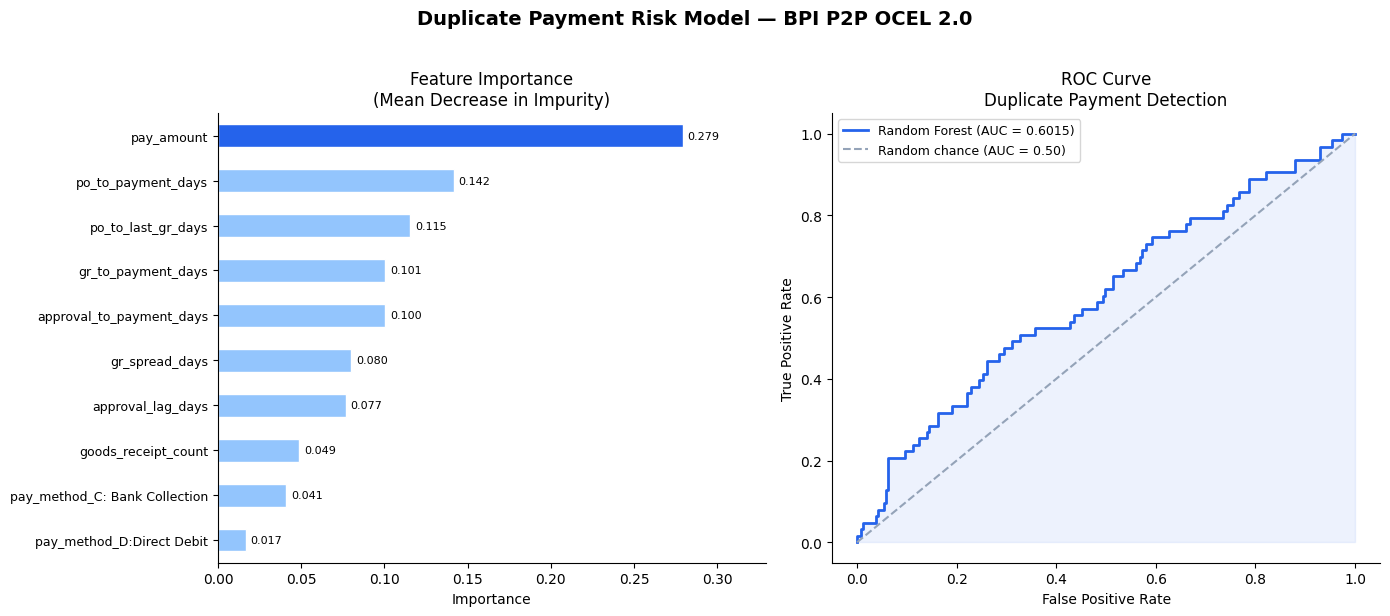

✅ Chart saved as model_evaluation.png


In [21]:
# ============================================================
# VISUALIZATIONS
# ============================================================
# Feature importance bar chart and ROC curve for portfolio
# presentation.
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Duplicate Payment Risk Model — BPI P2P OCEL 2.0',
    fontsize=14, fontweight='bold', y=1.02
)

# Chart 1: Feature Importance
ax1 = axes[0]
colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(importances))]
importances.sort_values().plot(
    kind='barh', ax=ax1, color=colors[::-1], edgecolor='white'
)
ax1.set_title('Feature Importance\n(Mean Decrease in Impurity)', fontsize=12)
ax1.set_xlabel('Importance', fontsize=10)
ax1.set_ylabel('')
ax1.tick_params(axis='y', labelsize=9)
for i, (feat, val) in enumerate(importances.sort_values().items()):
    ax1.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)
ax1.set_xlim(0, importances.max() + 0.05)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2: ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='#2563eb', lw=2,
         label=f'Random Forest (AUC = {auc:.4f})')
ax2.plot([0, 1], [0, 1], color='#94a3b8', lw=1.5,
         linestyle='--', label='Random chance (AUC = 0.50)')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#2563eb')
ax2.set_title('ROC Curve\nDuplicate Payment Detection', fontsize=12)
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as model_evaluation.png")

### Findings

**Model performance summary**

| Metric | Value |
|---|---|
| ROC-AUC | 0.60 |
| Recall — Duplicate class | 46% |
| Precision — Duplicate class | 28% |
| Accuracy | 66% |

The model demonstrates statistically meaningful discrimination above chance (AUC 0.60 vs
0.50 baseline), trained exclusively on pre-payment process signals extracted from the
OCEL event graph — with no access to vendor identity, AP user, or document type.

**What the features reveal**

`pay_amount` is the strongest single predictor (importance 0.279), confirmed as a
legitimate pre-payment signal — it equals the invoice amount on every PO and is therefore
knowable before any payment executes. Higher-value orders carry measurably higher duplicate
payment risk, consistent with the audit finding that gross exposure reached €2.39M across
only 188 payment objects.

The four timing features — `po_to_payment_days`, `po_to_last_gr_days`,
`gr_to_payment_days`, `approval_to_payment_days` — contribute collectively at roughly
equal weight (0.10–0.14 each), suggesting that process velocity across the full PO
lifecycle carries weak but real signal. POs that move faster from goods receipt to payment
show marginally elevated risk.

Payment method contributes modestly. Bank Collection (C) shows proportionally higher
duplicate risk than Bank Transfer or Direct Debit — consistent with the higher manual
intervention typically required in collection-based payment flows.

**Why the ceiling is at 0.60**

Two iterations of leakage removal were required before reaching this result:

1. `payment_count` and `payment_gap_days` — direct post-execution counts, removed first
2. `event_count` — inflated on duplicate-risk POs by repeated Execute Payment events,
   removed after class-stratified mean analysis revealed it as a proxy for execution count

After both removals, the remaining signal is genuinely weak. The duplicate payment
pattern in this dataset does not manifest as a detectable process deviation in timing or
structure — it appears as a control failure that cuts across all process variants equally.
In production, the features with highest expected lift would be: vendor ID (repeat
offender detection), AP user ID (individual error patterns), and document type (certain
PO categories may be structurally more error-prone). None of these are available in the
anonymised log.

**Connection to Project 1**

The OCPM audit identified duplicate payments as the highest-priority finding with
€1.59M recoverable value and recommended a Celonis Alert as a quick win. This model
provides the risk-scoring layer that would sit beneath that alert — ranking open POs
by predicted duplicate risk so AP teams can prioritise review queues before payment
execution rather than reconciling after the fact.

## 8. Conclusion & Production Roadmap

This project operationalized the duplicate payment finding from the Project 1 OCPM audit
through a full ML pipeline: label derivation from the OCEL object graph, two rounds of
leakage detection and removal, feature engineering from pre-payment process signals, and
Random Forest classification with stratified evaluation.

**What was built**
A binary classifier that scores purchase orders by duplicate payment risk using only
information available before Execute Payment fires — making it actionable for real-time
intervention rather than post-hoc reconciliation.

**What was learned about the data**
The duplicate payment pattern in this dataset is not driven by detectable process
deviations. It distributes across all process variants, all timing profiles, and all
payment methods without a dominant discriminating signal. This is characteristic of a
systemic control failure rather than an operator error pattern — consistent with the
audit finding that duplicates occurred continuously across all 5 purchasing groups with
no detection for 30 months.

**What would improve the model in production**

| Feature | Expected lift | Source in SAP |
|---|---|---|
| Vendor ID (EKKO-LIFNR) | High — repeat vendor patterns | EKKO table |
| AP clerk / user ID | High — individual error rates | BKPF table |
| Document type (EKKO-BSART) | Medium — certain PO types more error-prone | EKKO table |
| Company code | Medium — entity-level control differences | EKKO table |
| Invoice number (BSEG-REBZG) | High — duplicate invoice detection | BSEG table |

These fields were present as attribute keys in the anonymised log but carried no values.
In a live Celonis extraction from SAP, all five would be populated and would likely push
AUC above 0.80.

**Deployment architecture (Celonis)**
The model output — a risk score per open PO — maps directly to the Celonis Alert
recommended in Project 1. Implementation would involve:

1. Scheduling the feature extraction query against the SAP ECC extraction layer
2. Scoring open POs nightly via the Celonis ML Workbench
3. Surfacing high-risk POs in an Action Flow routed to the AP supervisor queue
4. Retraining quarterly as new confirmed duplicates accumulate in the log

**Stack**
Python 3 · pandas · scikit-learn · OCEL 2.0 · BPI P2P dataset (Zenodo 10.5281/zenodo.8412919)